# IAA Laboratori 11 -  eXplainable AI (XAI)

En aquest bloc de notes, introduiré dos llibreries: [SHAP (SHapley Additive exPlanations)](https://shap.readthedocs.io/en/latest/index.html) i [LIME (Local Interpretable Model-agnostic Explanations)](https://lime-ml.readthedocs.io/en/latest/). 

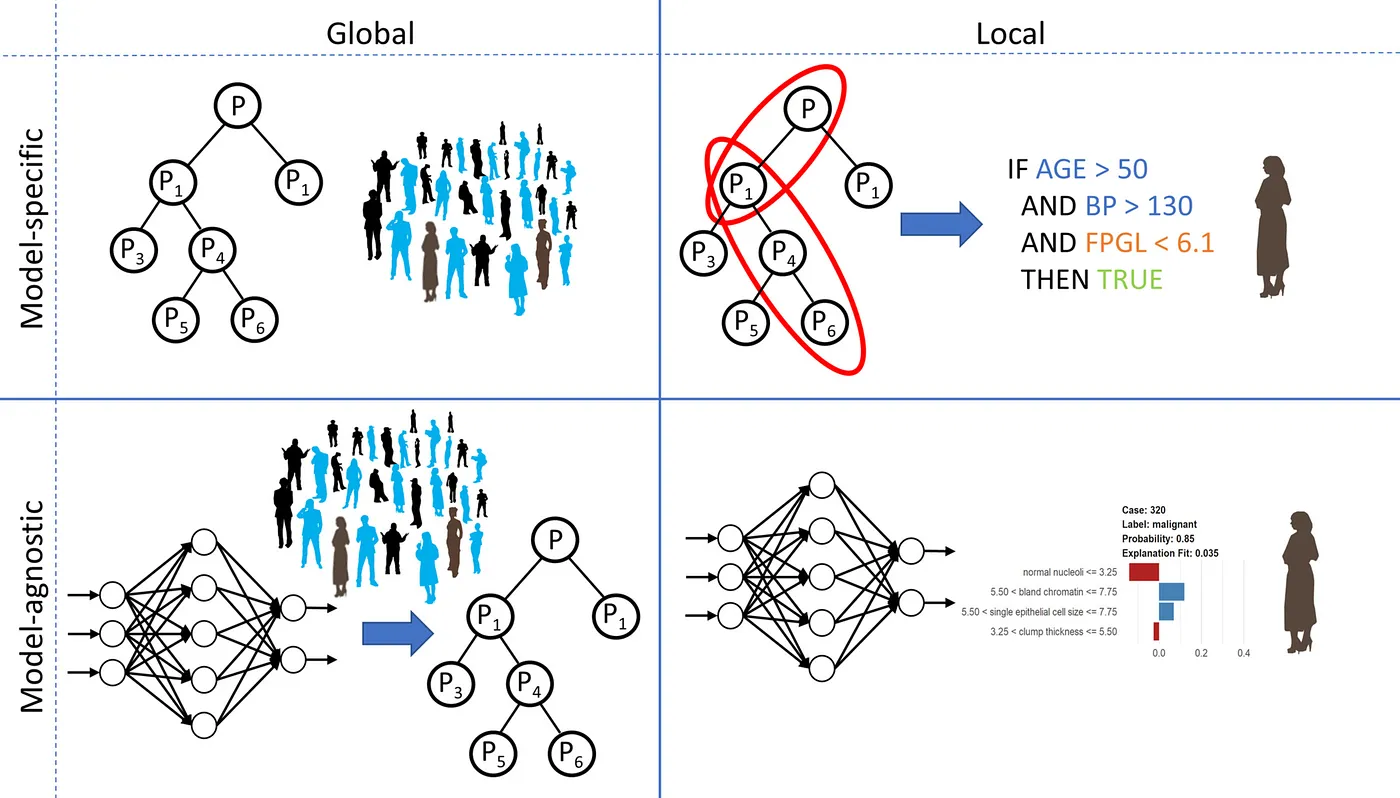

**intrinsic vs post-hoc**  <br>
Intrinsic machine learning models are intrinsically interpretable. Common examples are decision trees and sparse linear models, where you can purposely restrict the complexity of the model. Post-hoc interpretation is the application of methods to analyse the model after it has been trained. A typical example of post-hoc interpretation is permutation feature importance which is computed for tree-based models.

**model-specific vs model-agnostic**  <br>
Interpretation tools can either be model-specific or model-agnostic. An example of model-specific interpretability are the weights of a regression model. Model-agnostic interpretability methods are not allowed access to the model internals such as the weights or other parameters. These methods solely look at feature inputs and outputs. An example of a model-agnostic interpretation method are partial dependence plots (PDP).

**local vs global**  <br>
Local or global explanations are related to the scope of the explanation. A local explanation means that the interpretation method explain an individuel prediction, whereas a global interpretation method will explain the global model behaviour.

The following will attempt to provide an intuition of fundamental explainable AI methods.

## Preparació de l'entorn

In [1]:
# Upgrade packages
#%pip install shap 
#%pip install lime
#%pip install lightgbm hyperopt

In [2]:
## Data processing
import pandas as pd
import numpy as np

import urllib
import io
import os


## XAI support
import shap
import lime 
from lime import lime_tabular

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split

from hyperopt import hp, tpe
from hyperopt import space_eval
from hyperopt.fmin import fmin

## Visualization
import matplotlib.pyplot as plt
import plotly.offline as py
import plotly.graph_objs as go
from plotly import tools
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import cufflinks as cf

# Hiding warnings 
import warnings

In [3]:
# Display images and HTML datatables
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from IPython.display import display, HTML
show_html = lambda html: display(HTML(html))

# Time
from time import time
from datetime import timedelta
init_time = time()

## Visualization
pd.set_option('display.float_format', '{:.3f}'.format)
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)

# Hiding warnings 
warnings.filterwarnings("ignore")

## Wine Quality
Donated on 10/6/2009


The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. For more details, consult: http://www.vinhoverde.pt/en/ or the reference [Cortez et al., 2009].  Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

These datasets can be viewed as classification or regression tasks.  The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods.

Has Missing Values?

No


In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets


X.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
dtypes: float64(11)
memory usage: 558.5 KB


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [6]:
y_train

,quality
4534,4
4435,6
6201,6
1933,5
4630,6
...,...
3749,6
3040,5
338,6
3092,8


In [7]:
y_train['quality'] = y_train['quality'].apply(lambda x: 0 if x < 6 else 1)
y_val['quality'] = y_val['quality'].apply(lambda x: 0 if x < 6 else 1)
y_test['quality'] = y_test['quality'].apply(lambda x: 0 if x < 6 else 1)



In [8]:
import lightgbm as lgb
params = {
    'max_depth': 6,
    'min_child_weight': 0,
    'learning_rate': 0.5,  # Ensure this is a float
    'colsample_bytree': 0.75,  # Ensure this is a float
    'subsample': 1,
    'reg_lambda': 1,
    'n_estimators': 150,
    'objective': 'binary',
    'verbose': -1  # Setting verbose here
}

# Create the LGBMClassifier model with the specified parameters
lgb_model = lgb.LGBMClassifier(**params)

# Fitting the model on the training set and controlling for overfitting with early stopping
model = lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50)]  # Using early_stopping as a callback
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[47]	valid_0's binary_logloss: 0.415864


Confusion matrix:


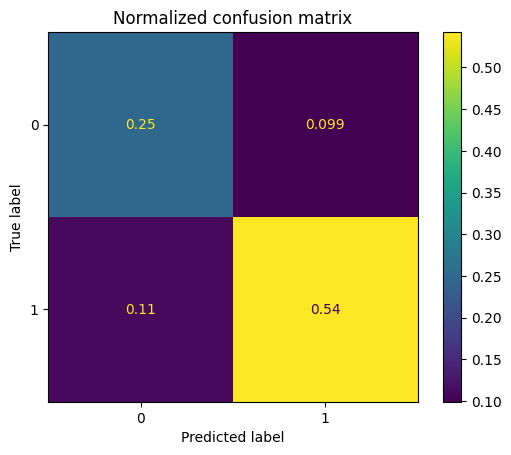

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       451
           1       0.85      0.83      0.84       849

    accuracy                           0.79      1300
   macro avg       0.77      0.77      0.77      1300
weighted avg       0.79      0.79      0.79      1300



Done!


In [9]:
def model_assessment(model, X, y):

    # Get the confusion matrix.
    print("Confusion matrix:")
    disp = ConfusionMatrixDisplay.from_estimator(model, X, y,  normalize='all')

    disp.ax_.set_title("Normalized confusion matrix")

    plt.show()

    # Produce a classification report.
    print("Classification Report:")
    pred = model.predict(X)
    print(classification_report(y, pred))
    print('\n')
    print("Done!")

model_assessment(model, X_test, y_test)

In [10]:
def objective(params):

    # Here is a list of hyperparameters that will be considered when optimising.
    # Each of those parameters will either be an integer (if int() wrapping is used in the dictionary below, e.g.'max_depth')
    # or a floating point value (as indicated by {:.3f}).
    # This is not an exhaustive list of what could be tuned but these parameters are usually considered key in practice.
    params = {
        'max_depth': int(params['max_depth']),
        'num_leaves': int(params['num_leaves']),
        'min_child_weight': '{:.3f}'.format(params['min_child_weight']),
        'colsample_bytree': '{:.3f}'.format(params['colsample_bytree']),
        'subsample': '{:.3f}'.format(params['subsample']),
        'n_estimators': int(params['n_estimators']),
        'verbose': -1
    }

    # Here is the model that will be using the hyperparameters above.
    clf = lgb.LGBMClassifier(objective = 'binary',
                             **params)

    # Here is the scoring function - we will be ensuring that the "score" variable takes an as small as possible value.
    # To be precise, we are minimising the mean log loss generated by the model in the process of cross-validation on the training set.
    # We have chosen mean log loss as the score given it is one of the typical accuracy measures used in hyperoptimisation for
    # binary classification problems.
    score = cross_val_score(clf,
                            X_train,
                            y_train,
                            scoring="neg_log_loss",
                            cv = StratifiedKFold(shuffle=True, random_state=42)).mean()*(-1)

    # The log loss is found for each set of parameters.
    print("Log loss of {:.3f} for the selected parameters {}".format(score, params))
    return score

# These are the distributions from which sample values of hyperparameters will be generated for optimisations.
# Each iteration (their number is define by max_evals below) will be based on a different set.
space = {
    'max_depth':        hp.choice('max_depth', np.arange(2, 63, 1, dtype=int)),
    'num_leaves':       hp.choice('num_leaves', np.arange(7, 4000, 20, dtype=int)),
    'min_child_weight': hp.choice('min_child_weight', np.arange(0.01, 0.5, 0.05)),
    'colsample_bytree': hp.choice('colsample_bytree', np.arange(0.4, 0.9, 0.05)),
    'subsample':        hp.uniform('subsample', 0.4, 1),
    'n_estimators':     hp.choice('n_estimators', np.arange(50, 5000, 50, dtype=int)),
}

# The command below runs the process.
optimal = fmin(fn=objective,
            space = space,
            algo = tpe.suggest,
            timeout=90,
            max_evals = 3)

# Let us extract the optimal values.
optimal = space_eval(space, optimal)
print("Optimal parameters: {}".format(optimal))

Log loss of 0.963 for the selected parameters {'max_depth': 9, 'num_leaves': 887, 'min_child_weight': '0.110', 'colsample_bytree': '0.650', 'subsample': '0.441', 'n_estimators': 4350, 'verbose': -1}
Log loss of 0.807 for the selected parameters {'max_depth': 25, 'num_leaves': 3327, 'min_child_weight': '0.460', 'colsample_bytree': '0.400', 'subsample': '0.996', 'n_estimators': 4450, 'verbose': -1}
 67%|██████▋   | 2/3 [02:31<01:15, 75.77s/trial, best loss: 0.8071723550998249]
Optimal parameters: {'colsample_bytree': 0.4, 'max_depth': 25, 'min_child_weight': 0.46, 'n_estimators': 4450, 'num_leaves': 3327, 'subsample': 0.996177638783258}


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[93]	valid_0's binary_logloss: 0.381998
Confusion matrix:


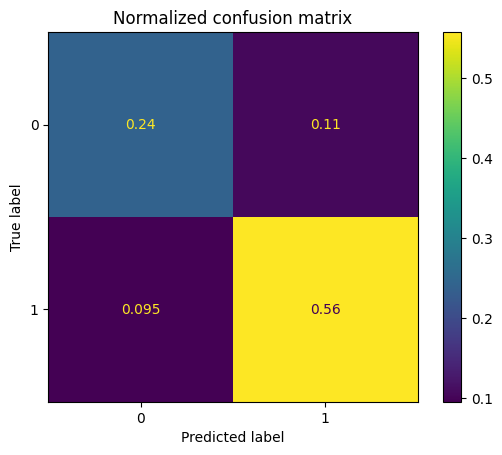

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.69      0.70       451
           1       0.84      0.85      0.85       849

    accuracy                           0.80      1300
   macro avg       0.78      0.77      0.78      1300
weighted avg       0.80      0.80      0.80      1300



Done!


In [11]:
optimal['verbose'] = -1
lgb_model = lgb.LGBMClassifier(objective = 'binary', **optimal)
lgb_opt = lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50)]  # Using early_stopping as a callback
)


model_assessment(lgb_opt, X_test, y_test)

# LIME (Local Interpretable Model-agnostic Explanations)

As the name suggests, this is a model agnostic technique to generate local explanations to the model. The core idea behind the technique is quite intuitive. Suppose we have a complex classifier, with a highly non-linear decision boundary. But if we zoom in and look at a single prediction, the behaviour of the model in that locality can be explained by a simple interpretable model (mostly linear).

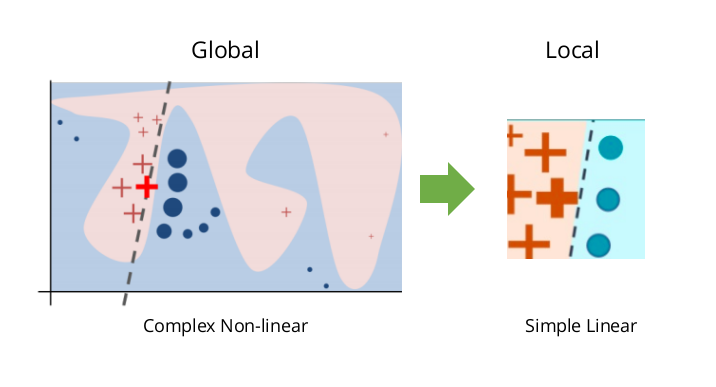



LIME uses a local surrogate model trained on perturbations of the data point we are investigating for explanations. This ensures that even though the explanation does not have global fidelity (faithfulness to the original model) it has local fidelity.

## What are explanations?

Intuitively, an explanation is a local linear approximation of the model's behaviour. While the model may be very complex globally, it is easier to approximate it around the vicinity of a particular instance. While treating the model as a black box, we perturb the instance we want to explain and learn a sparse linear model around it, as an explanation. The figure above illustrates the intuition for this procedure. The model's decision function is represented by the blue/pink background, and is clearly nonlinear. The bright red cross is the instance being explained (let's call it X). We sample instances around X, and weight them according to their proximity to X (weight here is indicated by size). We then learn a linear model (dashed line) that approximates the model well in the vicinity of X, but not necessarily globally. 

In [14]:
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['bad', 'good'],
    mode='classification'
)


lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[1],
    predict_fn=lgb_opt.predict_proba
)
lime_exp.show_in_notebook(show_table=True)

## PLAYTIME
<div class="alert alert-success">
PLAYTIME: Check the documentation of lime_tabular.LimeTabularExplainer and play with the kernel width. How the explanations are changing for the previous sample?
</div>

[lime_tabular.LimeTabularExplainer](https://lime-ml.readthedocs.io/en/latest/lime.html#module-lime.lime_tabular)

In [15]:
lime_exp.predict_proba

array([0.83862245, 0.16137755])

## Submodular pick and global explanations

There is another technique “submodular pick” to find a handful of explanations which try to explain most of the cases.

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

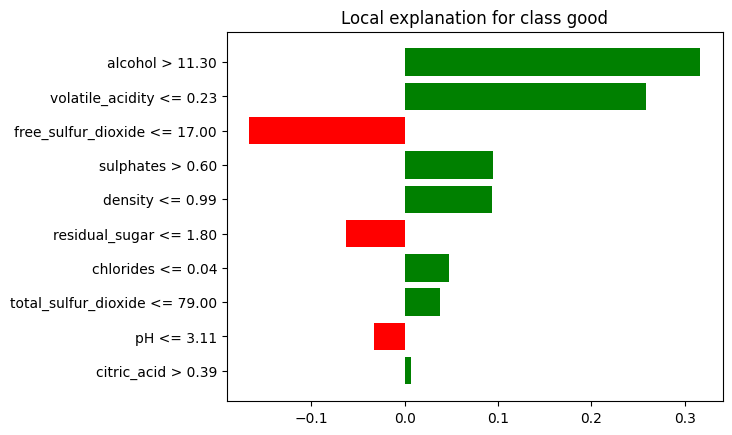

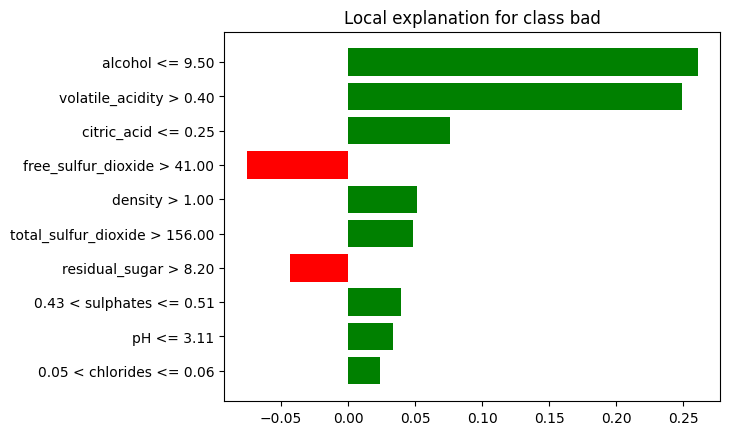

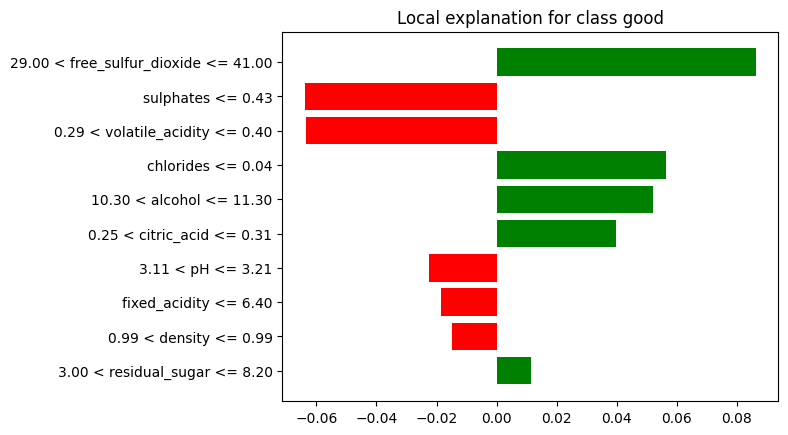

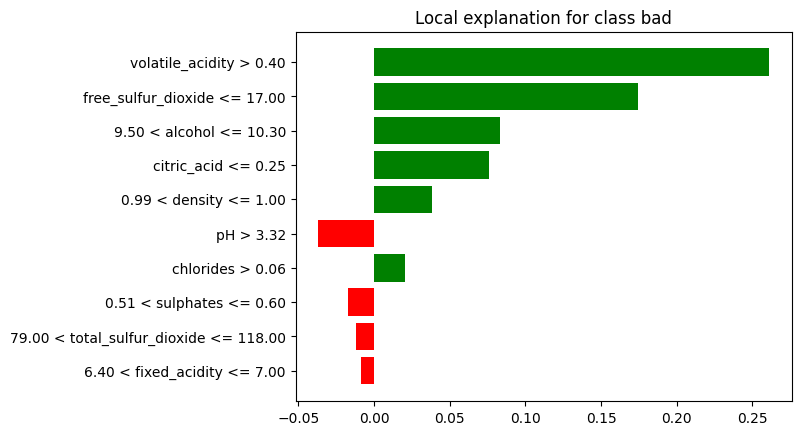

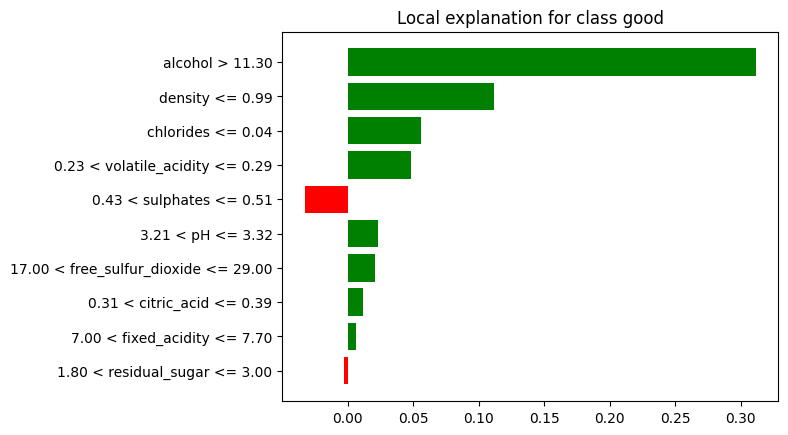

In [16]:
from lime import submodular_pick


sp_obj = submodular_pick.SubmodularPick(lime_explainer, X_train.values, lgb_opt.predict_proba, sample_size=500, num_features=10, num_exps_desired=5)
#Plot the 5 explanations
[exp.as_pyplot_figure(label=exp.available_labels()[0]) for exp in sp_obj.sp_explanations];
# Make it into a dataframe
W_pick=pd.DataFrame([dict(this.as_list(this.available_labels()[0])) for this in sp_obj.sp_explanations]).fillna(0)
 
W_pick['prediction'] = [this.available_labels()[0] for this in sp_obj.sp_explanations]
 
#Making a dataframe of all the explanations of sampled points
W=pd.DataFrame([dict(this.as_list(this.available_labels()[0])) for this in sp_obj.explanations]).fillna(0)
W['prediction'] = [this.available_labels()[0] for this in sp_obj.explanations]
 
#Plotting the aggregate importances
np.abs(W.drop("prediction", axis=1)).mean(axis=0).sort_values(ascending=False).head(
    25
).sort_values(ascending=True).iplot(kind="barh")
 
#Aggregate importances split by classes
grped_coeff = W.groupby("prediction").mean()
 
grped_coeff = grped_coeff.T
grped_coeff["abs"] = np.abs(grped_coeff.iloc[:, 0])
grped_coeff.sort_values("abs", inplace=True, ascending=False)
grped_coeff.head(25).sort_values("abs", ascending=True).drop("abs", axis=1).iplot(
    kind="barh", bargap=0.5
) 



There are two charts where we have aggregated the explanations across the 500 points we sampled from out test set(we can run it on all test data points, but chose to do sampling only cause of computation).

The first chart aggregates the effect of the feature across 'bad' and 'good' cases and ignores the sign when calculating the mean. This gives you an idea of what features were important in the larger sense.

The second chart splits the inference across the two labels and looks at them separately. This chart lets us understand which feature was more important in predicting a particular class.

# SHAP (SHapley Additive exPlanations)

SHAP is a game theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions.

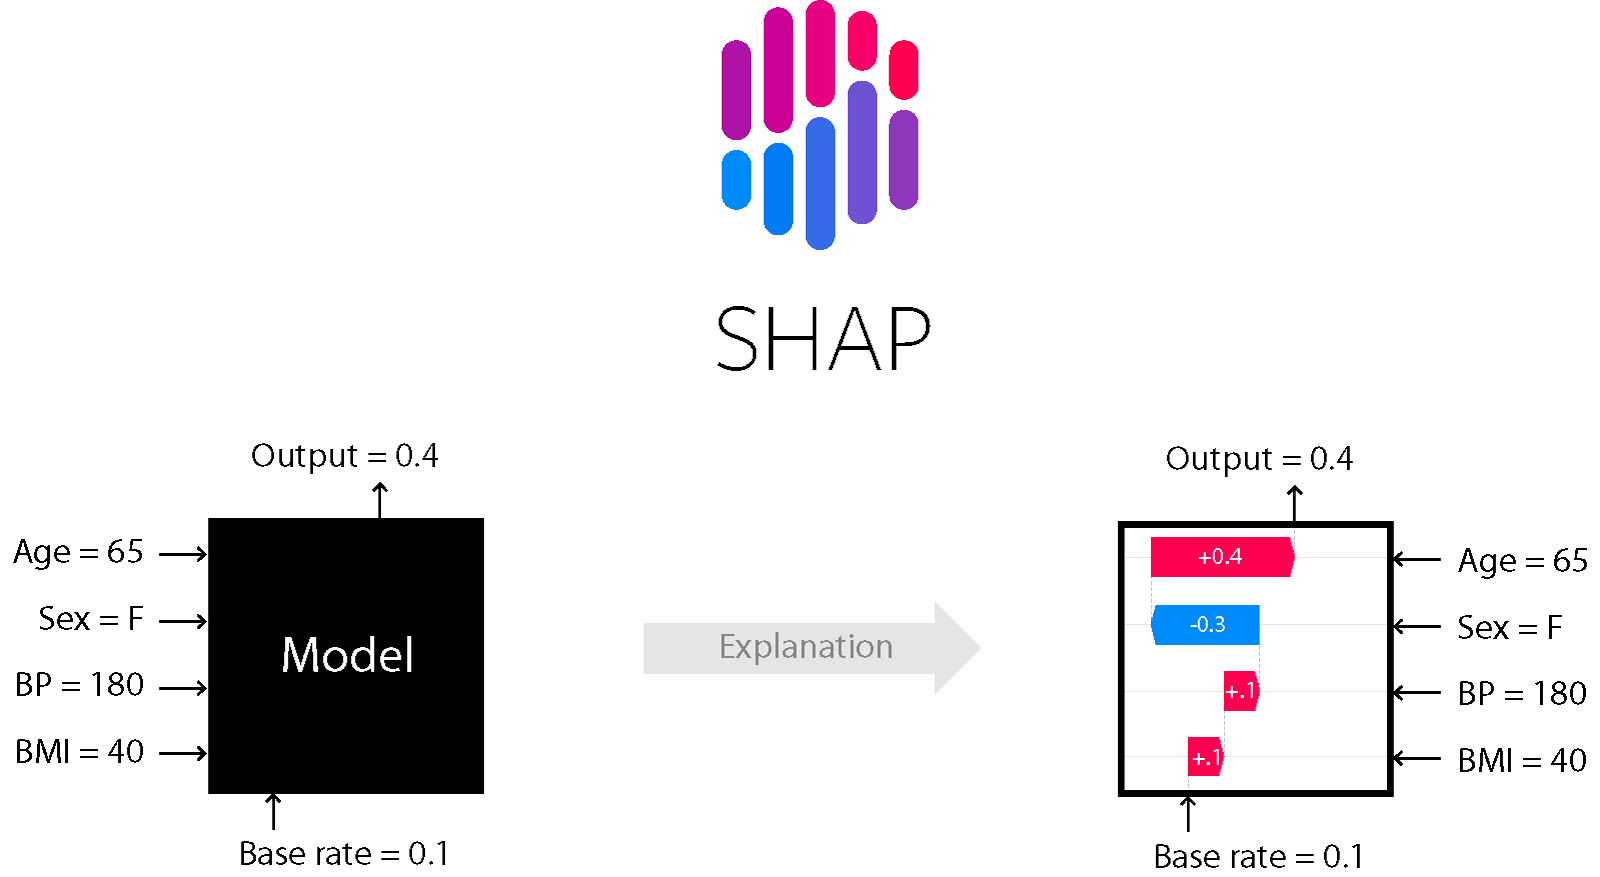

## Explaining a linear regression model

Before using Shapley values to explain complicated models, it is helpful to understand how they work for simple models. One of the simplest model types is standard linear regression, and so below we train a linear regression model on the California housing dataset. This dataset consists of 20,640 blocks of houses across California in 1990, where our goal is to predict the natural log of the median home price from 8 different features:

    MedInc - median income in block group

    HouseAge - median house age in block group

    AveRooms - average number of rooms per household

    AveBedrms - average number of bedrooms per household

    Population - block group population

    AveOccup - average number of household members

    Latitude - block group latitude

    Longitude - block group longitude


In [17]:
import sklearn

import shap

# a classic housing price dataset
X, y = shap.datasets.california(n_points=1000)

X100 = shap.utils.sample(X, 100)  # 100 instances for use as the background distribution

# a simple linear model
lr = sklearn.linear_model.LinearRegression()
lr.fit(X, y)

LinearRegression()

### Examining the model coefficients

The most common way of understanding a linear model is to examine the coefficients learned for each feature. These coefficients tell us how much the model output changes when we change each of the input features:

In [18]:
print("Model coefficients:\n")
for i in range(X.shape[1]):
    print(X.columns[i], "=", lr.coef_[i].round(5))



Model coefficients:

MedInc = 0.42563
HouseAge = 0.01033
AveRooms = -0.1161
AveBedrms = 0.66385
Population = 3e-05
AveOccup = -0.26096
Latitude = -0.46734
Longitude = -0.46272


While coefficients are great for telling us what will happen when we change the value of an input feature, by themselves they are not a great way to measure the overall importance of a feature. This is because the value of each coefficient depends on the scale of the input features. If for example we were to measure the age of a home in minutes instead of years, then the coefficients for the HouseAge feature would become 0.0115 / (365∗24∗60) = 2.18e-8. Clearly the number of years since a house was built is not more important than the number of minutes, yet its coefficient value is much larger. This means that the magnitude of a coefficient is not necessarily a good measure of a feature’s importance in a linear model.

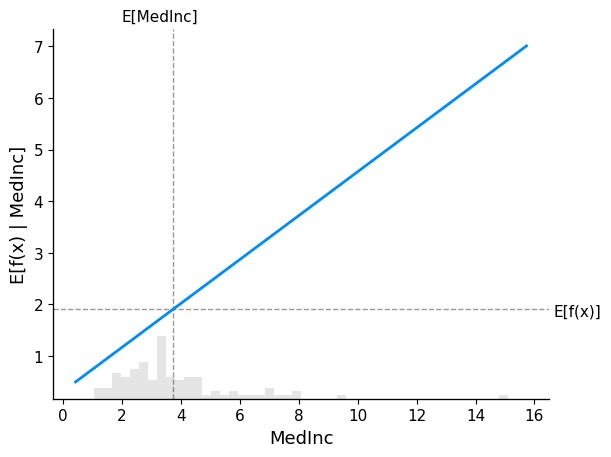

In [19]:
shap.partial_dependence_plot(
    "MedInc",
    lr.predict,
    X100,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

The gray horizontal line in the plot above represents the expected value of the model when applied to the California housing dataset. The vertical gray line represents the average value of the median income feature. Note that the blue partial dependence plot line (which is the average value of the model output when we fix the median income feature to a given value) always passes through the intersection of the two gray expected value lines. We can consider this intersection point as the “center” of the partial dependence plot with respect to the data distribution. The impact of this centering will become clear when we turn to Shapley values next.

### Reading SHAP values from partial dependence plots

The core idea behind Shapley value based explanations of machine learning models is to use fair allocation results from cooperative game theory to allocate credit for a model’s output f(x) among its input features. In order to connect game theory with machine learning models, it is necessary to both match a model’s input features with players in a game, and also match the model function with the rules of the game. Since in game theory a player can join or not join a game, we need a way for a feature to “join” or “not join” a model.

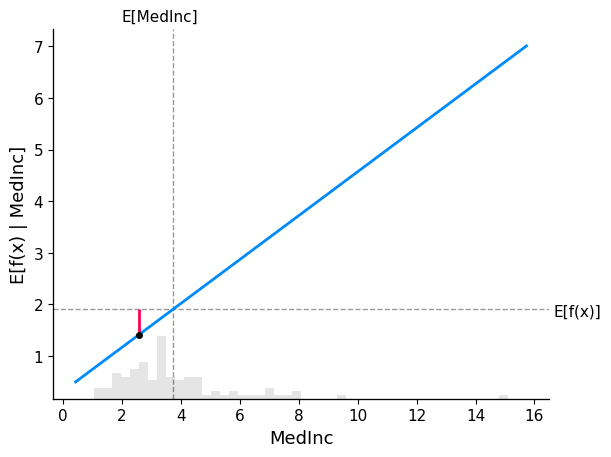

In [20]:
# compute the SHAP values for the linear model
explainer = shap.Explainer(lr.predict, X100)
shap_values = explainer(X)

# make a standard partial dependence plot
sample_ind = 20
shap.partial_dependence_plot(
    "MedInc",
    lr.predict,
    X100,
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

The close correspondence between the classic partial dependence plot and SHAP values means that if we plot the SHAP value for a specific feature across a whole dataset we will exactly trace out a mean centered version of the partial dependence plot for that feature:

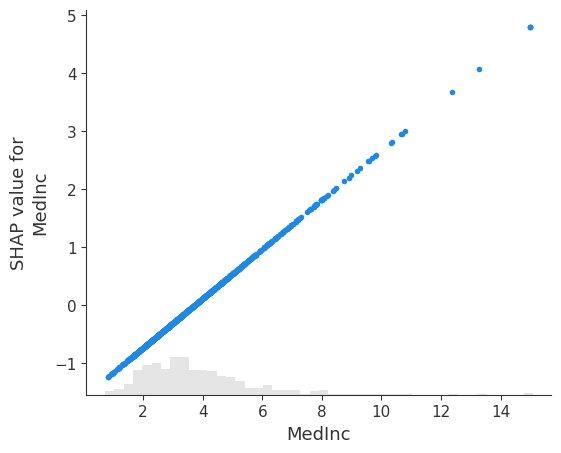

In [21]:
shap.plots.scatter(shap_values[:, "MedInc"])

### The additive nature of Shapley values


One of the fundamental properties of Shapley values is that they always sum up to the difference between the game outcome when all players are present and the game outcome when no players are present. For machine learning models this means that SHAP values of all the input features will always sum up to the difference between baseline (expected) model output and the current model output for the prediction being explained. The easiest way to see this is through a waterfall plot that starts at our background prior expectation for a home price, and then adds features one at a time until we reach the current model output :

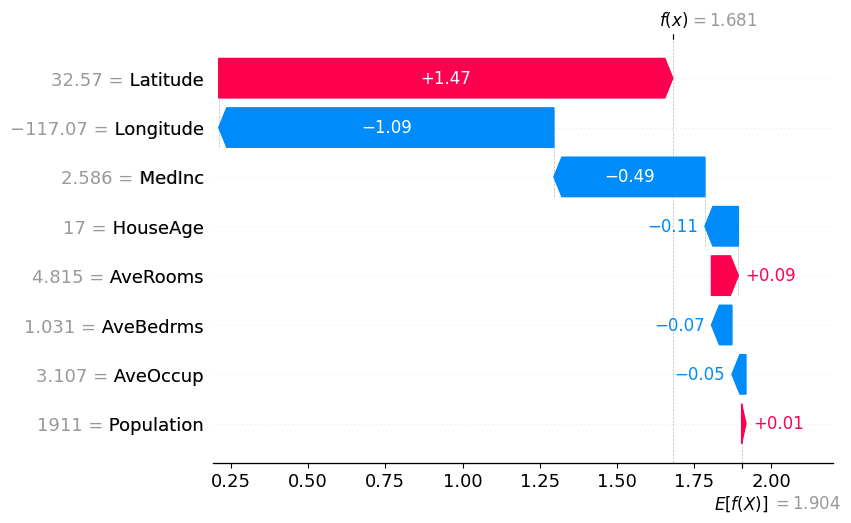

In [22]:
# the waterfall_plot shows how we get from shap_values.base_values to model.predict(X)[sample_ind]
shap.plots.waterfall(shap_values[sample_ind], max_display=14)



### Explaining an additive regression model

The reason the partial dependence plots of linear models have such a close connection to SHAP values is because each feature in the model is handled independently of every other feature (the effects are just added together). We can keep this additive nature while relaxing the linear requirement of straight lines. This results in the well-known class of generalized additive models (GAMs). While there are many ways to train these types of models (like setting an XGBoost model to depth-1), we will use InterpretMLs explainable boosting machines that are specifically designed for this.

ExplainableBoostingRegressor(interactions=0)

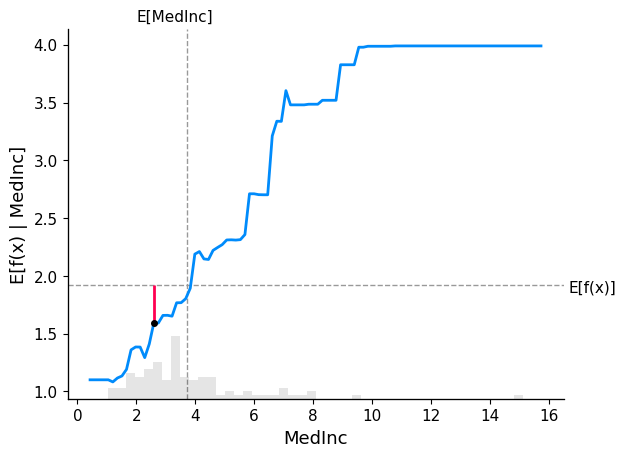

In [23]:
# fit a GAM model to the data
import interpret.glassbox

model_ebm = interpret.glassbox.ExplainableBoostingRegressor(interactions=0)
model_ebm.fit(X, y)

# explain the GAM model with SHAP
explainer_ebm = shap.Explainer(model_ebm.predict, X100)
shap_values_ebm = explainer_ebm(X)

# make a standard partial dependence plot with a single SHAP value overlaid
fig, ax = shap.partial_dependence_plot(
    "MedInc",
    model_ebm.predict,
    X100,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
    shap_values=shap_values_ebm[sample_ind : sample_ind + 1, :],
)

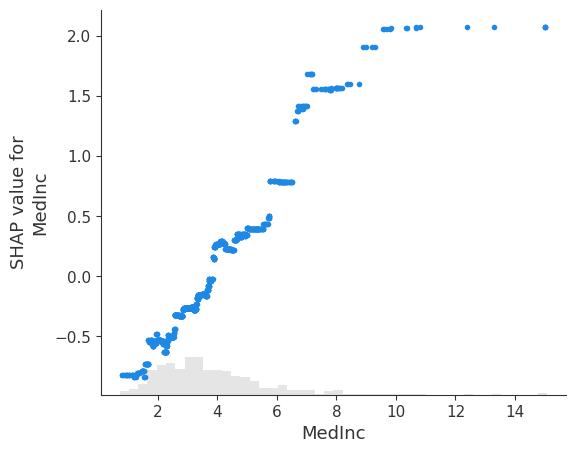

In [24]:
shap.plots.scatter(shap_values_ebm[:, "MedInc"])


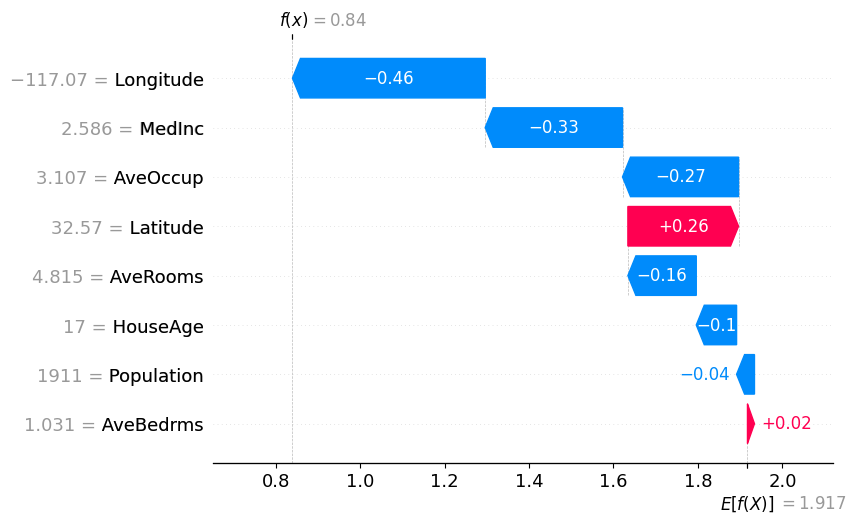

In [25]:
# the waterfall_plot shows how we get from explainer.expected_value to model.predict(X)[sample_ind]
shap.plots.waterfall(shap_values_ebm[sample_ind])

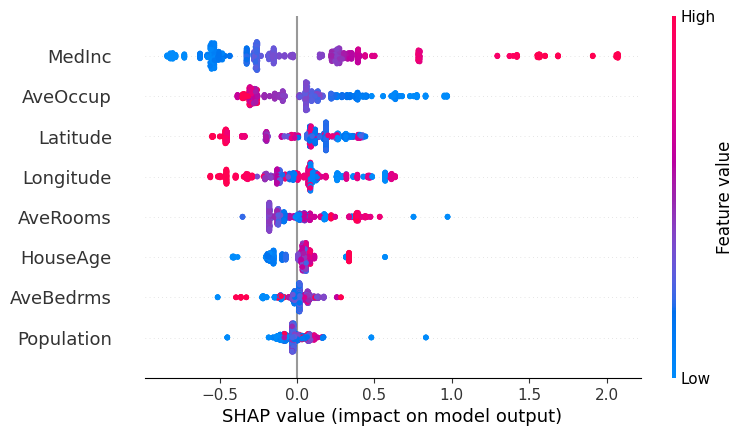

In [26]:
# the waterfall_plot shows how we get from explainer.expected_value to model.predict(X)[sample_ind]
shap.plots.beeswarm(shap_values_ebm)

### Application of SHAP to Wine dataset

Using SHAP, we will try to check

-   which features drive the global behaviour of the model,
-   what factors have the most influence on the classification of individual students, and
-   what the dependencies between features are.

Firstly, we need to get the Shapley values:

In [27]:
import shap

explainer = shap.TreeExplainer(lgb_opt)
shap_values = explainer.shap_values(X_test)

Now, we can produce global summary plots from the perspective of class "good" (1)

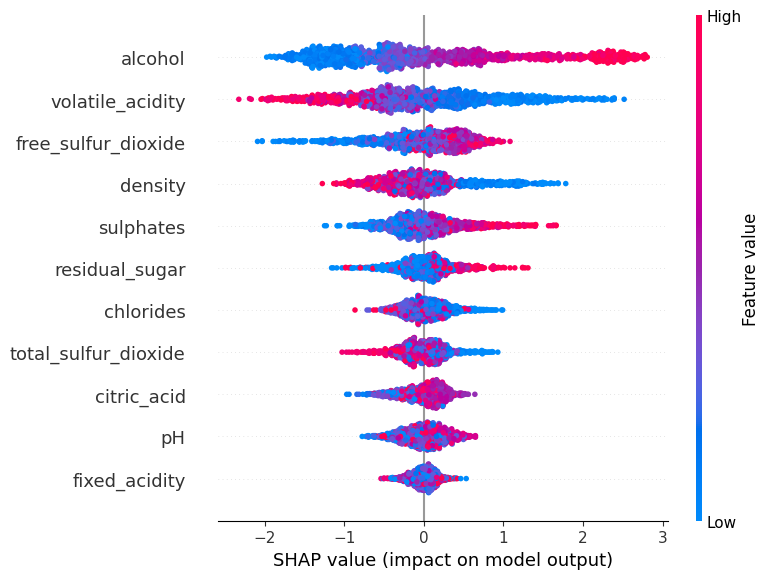

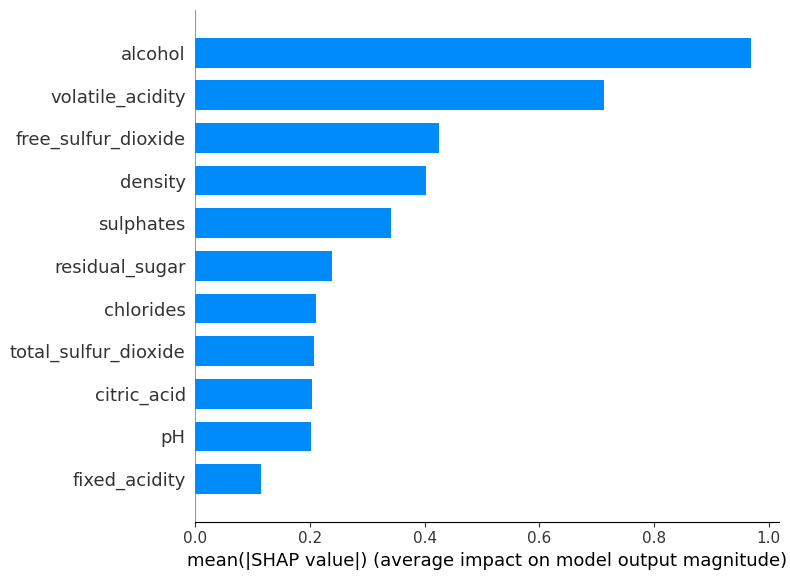

In [28]:
shap.initjs()

shap_explainer = shap.TreeExplainer(lgb_opt)
shap_values = shap_explainer.shap_values(X_test)

shap.summary_plot(shap_values[1], X_test)
shap.summary_plot(shap_values[1], X_test, plot_type="bar")

### PLAYTIME
<div class="alert alert-success">
PLAYTIME: Generate the same plots for instances in class 0. What is the link between these graphs and what has been generated for class 1? What are the 5 most important features which are driving this model's decisions?
How would you interpret the horizontal axis of the first summary plot above? What does a SHAP value of -1.5 mean
</div>




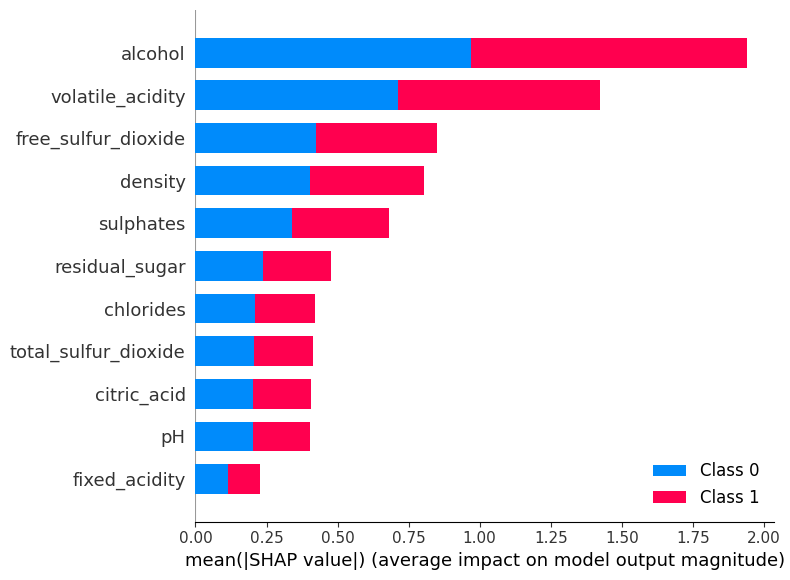

In [29]:
shap.summary_plot(shap_values, X_test)

After assesing the general importance of variables, let us focus on individual predictions for single observations. Drilling down into the details they can help us validate our model and find any hidden biases.

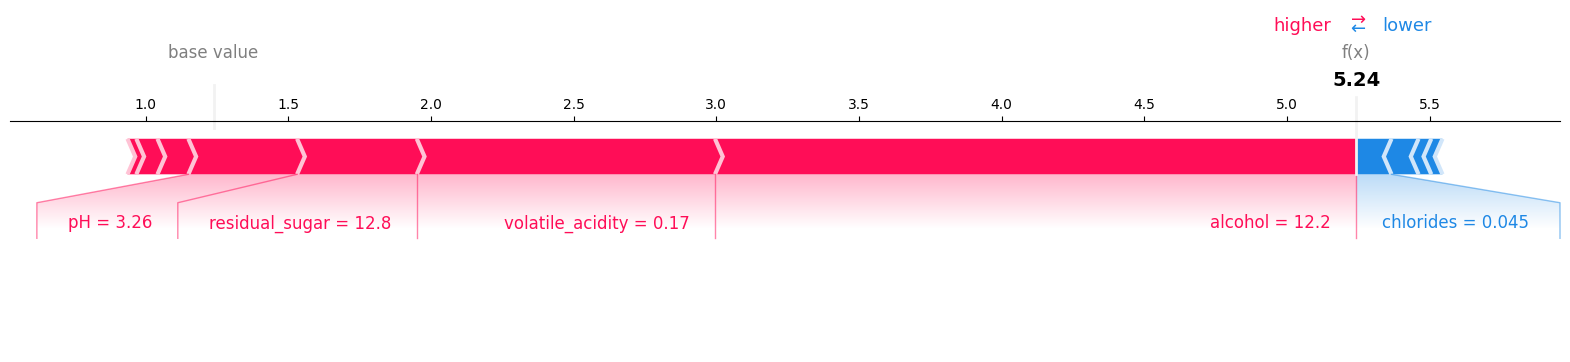

In [30]:
import matplotlib
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test.iloc[0,:], matplotlib=matplotlib)

These figures can be also presented in a form of waterfall/decision plots as below. Below, we give an example of a decision plot for the 0 sample in our test set. It aims to display the same information as the last force plot from above.

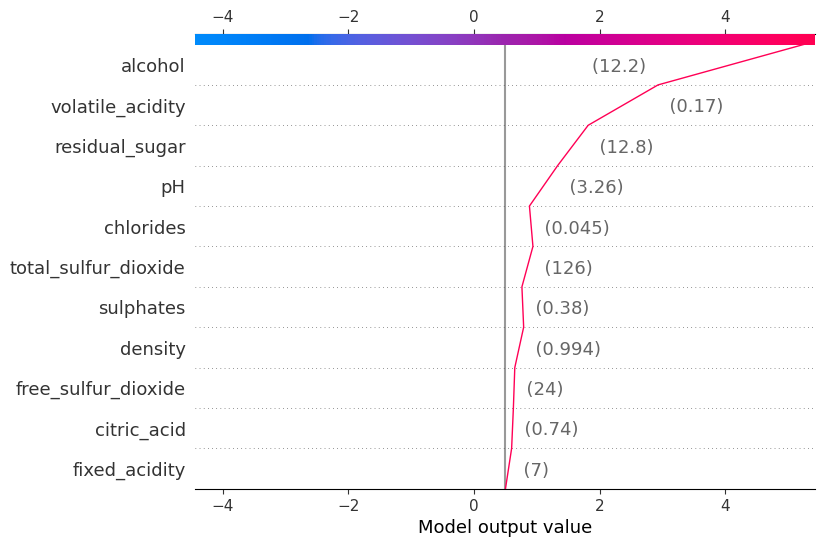

In [31]:
row=00

shap.force_plot(
    base_value=explainer.expected_value[1],
    shap_values=shap_values[1][row],
    features=X_test.iloc[row],
    feature_names=X_test.columns,
    link="identity",
    out_names="bad",
)
 
# We provide new_base_value as the cutoff probability for the classification mode
# This is done to increase the interpretability of the plot 
shap.decision_plot(
    base_value=explainer.expected_value[1],
    shap_values=shap_values[1][row],
    features=X_test.iloc[row],
    feature_names=X_test.columns.tolist(),
    link="identity",
    new_base_value=0.5,
)

### PLAYTIME
<div class="alert alert-success">
PLAYTIME: Create the plots for the five samples of the test dataset. According to these plots, which wine is most likely to be considered as "bad" (assuming our model is appropriate)? Are there any features which are important from the perspective of predictions on the local level for these 5 wines? 
</div>

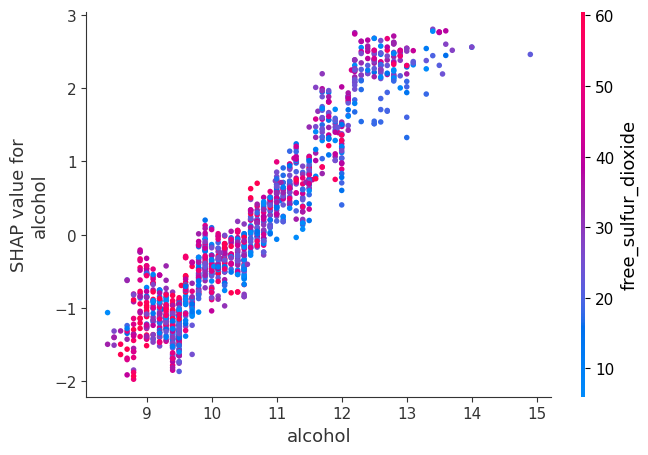

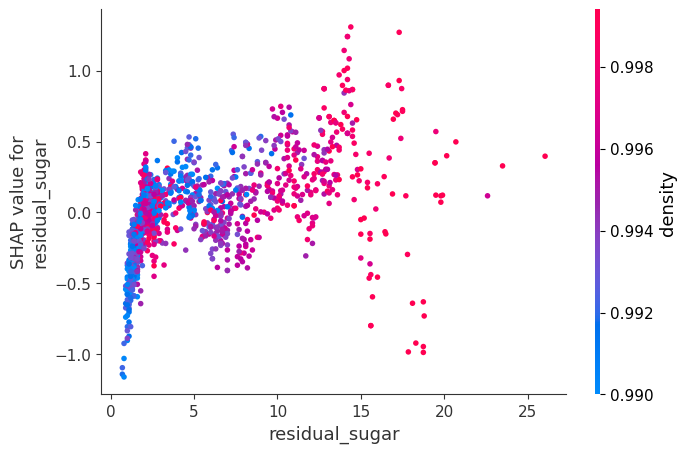

In [32]:
#Dependence Plots (analogous to PDP)
# create a SHAP dependence plot to show the effect of a single feature across the whole dataset
shap.dependence_plot("alcohol", shap_values=shap_values[1], features=X_test)
 
shap.dependence_plot("residual_sugar", shap_values=shap_values[1], features=X_test)

## PLAYTIME
<div class="alert alert-success">
PLAYTIME: Apply the EBM model as a classifier and compute the SHAP values. Which model would you choose as the most trustworthy based on the SHAP explanations?
</div>